# ST-GNN Model Results

Visualizza i risultati del modello salvato da `python main.py`.

> **Pre-requisito**: eseguire `python main.py` dalla root del progetto.

In [ ]:
import sys, json, os
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xarray as xr

from main import _normalize_dataset
from physiq_pv.model.st_gnn import STGNN
from physiq_pv.model.graph_builder import build_graph
from physiq_pv.data.dataset import PVDataset
from physiq_pv.data.quality_score import compute_qs
from physiq_pv.data.load_kwp import load_kwp
from physiq_pv.data.sentinel_hourly_loader import load_sentinel_hourly, merge_with_weather
from torch.utils.data import DataLoader

sns.set_theme(style='darkgrid')
CKPT = '../checkpoints'

with open(f'{CKPT}/model_config.json') as f:
    cfg = json.load(f)
with open(f'{CKPT}/loss_history.json') as f:
    _lh = json.load(f)
loss_history     = _lh['train'] if isinstance(_lh, dict) else _lh
val_loss_history = _lh.get('val', []) if isinstance(_lh, dict) else []

model = STGNN(**cfg)
model.load_state_dict(torch.load(f'{CKPT}/model.pt', map_location='cpu'))
model.eval()
print(f'Model: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Train loss: {[round(l, 4) for l in loss_history]}')
if val_loss_history:
    print(f'Val   loss: {[round(l, 4) for l in val_loss_history]}')
    print(f'Best val:   {min(val_loss_history):.4f} @ epoch {val_loss_history.index(min(val_loss_history))+1}')

# Load Sentinel hourly data (1116 plants, 5743 hours, 2019-03 to 2019-12)
print('\nLoading Sentinel hourly data...')
ds = load_sentinel_hourly(
    sentinel_dir='/data/SentinelPV/energy_data/piemonte_energy_data/single_ups',
    year=2019,
    plant_mapping_path='../data/plant_mapping.csv',
    energy_coords_path='../data/energy_with_coordinates.csv',
)
ds = merge_with_weather(ds, pvgis_path='../data/piedmont_pvgis_2019.nc')
ds = _normalize_dataset(ds)
qs = compute_qs(ds)
edge_index, edge_weight = build_graph(ds['lat'].values, ds['lon'].values, max_dist_km=20.0)
print(f'Graph: {ds.sizes["plant"]} nodes, {edge_index.shape[1]} edges')

kwp = None
if os.path.exists('../data/plant_mapping.csv') and os.path.exists('../data/energy_with_coordinates.csv'):
    kwp = load_kwp('../data/plant_mapping.csv', '../data/energy_with_coordinates.csv', ds.sizes['plant'])
    print(f'Real kWp loaded: {int(np.sum(np.isfinite(kwp)))}/{ds.sizes["plant"]} plants  range=[{np.nanmin(kwp):.0f}, {np.nanmax(kwp):.0f}] kW')

dataset = PVDataset(ds, qs, kwp=kwp)
loader  = DataLoader(dataset, batch_size=64, shuffle=False)
print(f'Dataset: {len(dataset)} samples  ({ds.sizes["plant"]} plants × {ds.sizes["time"]} hours)')

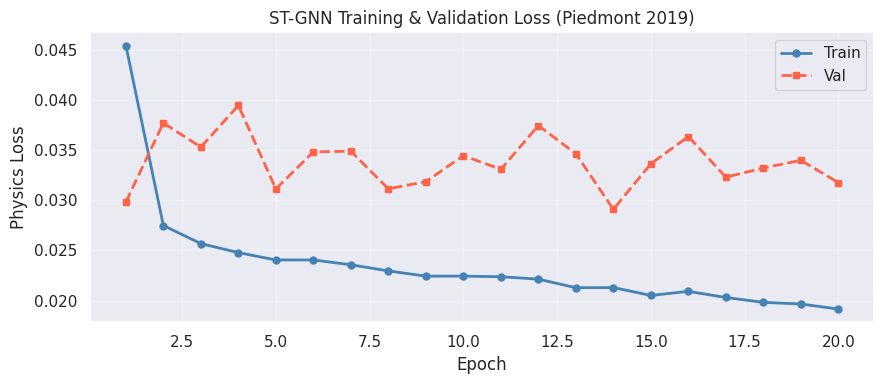

=== LOSS CURVE ===
  Epoch  1: train=0.0454  val=0.0298
  Epoch  2: train=0.0275  val=0.0377  (+39.5%)
  Epoch  3: train=0.0257  val=0.0353  (+6.6%)
  Epoch  4: train=0.0248  val=0.0394  (+3.5%)
  Epoch  5: train=0.0241  val=0.0311  (+3.0%)
  Epoch  6: train=0.0241  val=0.0348  (-0.0%)
  Epoch  7: train=0.0236  val=0.0349  (+2.0%)
  Epoch  8: train=0.0230  val=0.0311  (+2.6%)
  Epoch  9: train=0.0224  val=0.0319  (+2.3%)
  Epoch 10: train=0.0224  val=0.0344  (-0.0%)
  Epoch 11: train=0.0224  val=0.0331  (+0.3%)
  Epoch 12: train=0.0221  val=0.0374  (+1.1%)
  Epoch 13: train=0.0213  val=0.0346  (+3.9%)
  Epoch 14: train=0.0213  val=0.0291  (-0.1%)
  Epoch 15: train=0.0205  val=0.0336  (+3.7%)
  Epoch 16: train=0.0209  val=0.0363  (-2.0%)
  Epoch 17: train=0.0203  val=0.0323  (+2.9%)
  Epoch 18: train=0.0198  val=0.0332  (+2.4%)
  Epoch 19: train=0.0197  val=0.0340  (+0.8%)
  Epoch 20: train=0.0192  val=0.0318  (+2.6%)
  Total drop: 57.8%
  Best val epoch: 14  val=0.0291


In [2]:
# Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(loss_history) + 1)
ax.plot(epochs, loss_history, 'o-', color='steelblue', linewidth=2, markersize=5, label='Train')
if val_loss_history:
    ax.plot(range(1, len(val_loss_history) + 1), val_loss_history, 's--', color='tomato', linewidth=2, markersize=5, label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Physics Loss')
ax.set_title('ST-GNN Training & Validation Loss (Piedmont 2019)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== LOSS CURVE ===")
for i, v in enumerate(loss_history):
    drop = f"  ({(loss_history[i-1]-v)/loss_history[i-1]*100:+.1f}%)" if i > 0 else ""
    val_str = f"  val={val_loss_history[i]:.4f}" if i < len(val_loss_history) else ""
    print(f"  Epoch {i+1:>2}: train={v:.4f}{val_str}{drop}")
total_drop = (loss_history[0] - loss_history[-1]) / loss_history[0] * 100
print(f"  Total drop: {total_drop:.1f}%")
if val_loss_history:
    best_ep = val_loss_history.index(min(val_loss_history)) + 1
    print(f"  Best val epoch: {best_ep}  val={min(val_loss_history):.4f}")

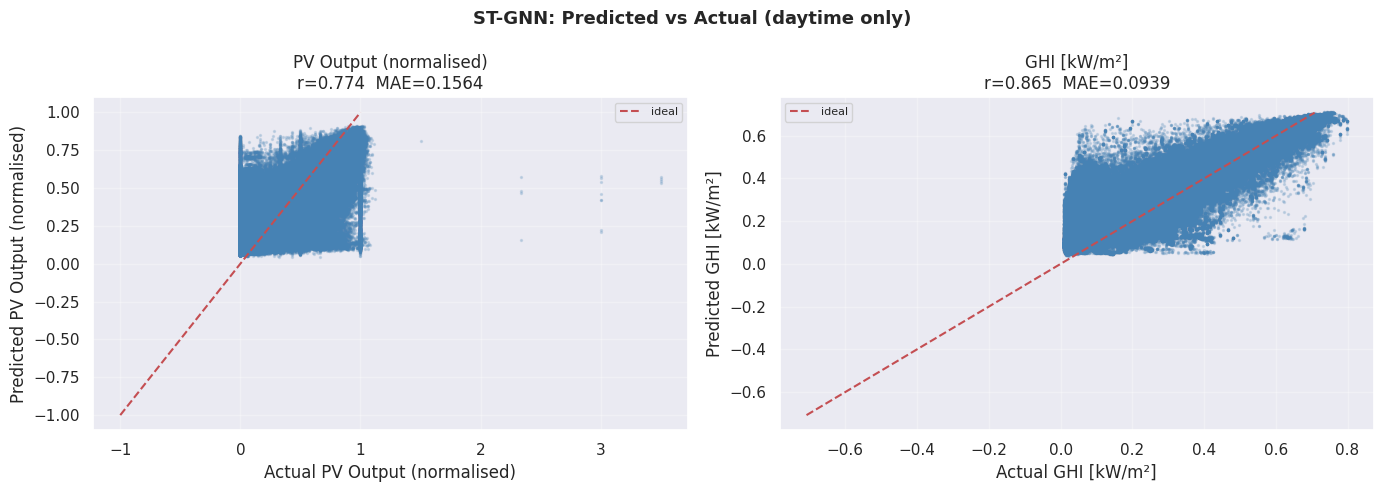


=== SCATTER METRICS (daytime, n=241,628) ===
  PV Output (normalised):
    r=0.774  MAE=0.1564  RMSE=0.2079  bias=-0.0052
    actual  range: [0.000, 3.500]  mean=0.378
    predicted range: [0.046, 0.910]  mean=0.373
    negative predictions: 0 (0.0%)
  GHI [kW/m²]:
    r=0.865  MAE=0.0939  RMSE=0.1212  bias=+0.0579
    actual  range: [0.010, 0.798]  mean=0.277
    predicted range: [0.039, 0.710]  mean=0.335
    negative predictions: 0 (0.0%)


In [3]:
# Inference: collect pred vs actual
all_pred_pv, all_true_pv = [], []
all_pred_ghi, all_true_ghi = [], []

with torch.no_grad():
    for i, (x, y_ghi, y_pv, qs_b, eta) in enumerate(loader):
        if i >= 200:
            break
        pg, pp = model(x, edge_index, edge_weight)
        all_pred_pv.append(pp.numpy())
        all_true_pv.append(y_pv.numpy())
        all_pred_ghi.append(pg.numpy())
        all_true_ghi.append(y_ghi.numpy())

pred_pv  = np.concatenate(all_pred_pv).ravel()
true_pv  = np.concatenate(all_true_pv).ravel()
pred_ghi = np.concatenate(all_pred_ghi).ravel()
true_ghi = np.concatenate(all_true_ghi).ravel()

day_mask   = true_ghi > 0.01
pred_pv_d, true_pv_d   = pred_pv[day_mask],  true_pv[day_mask]
pred_ghi_d, true_ghi_d = pred_ghi[day_mask], true_ghi[day_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (p, t, label) in zip(axes, [
    (pred_pv_d,  true_pv_d,  'PV Output (normalised)'),
    (pred_ghi_d, true_ghi_d, 'GHI [kW/m²]'),
]):
    lim = max(np.percentile(np.abs(t), 99), np.percentile(np.abs(p), 99))
    ax.scatter(t, p, s=2, alpha=0.2, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='ideal')
    corr = float(np.corrcoef(t, p)[0, 1])
    mae  = float(np.mean(np.abs(t - p)))
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label}\nr={corr:.3f}  MAE={mae:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('ST-GNN: Predicted vs Actual (daytime only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Text report ---
def _metrics(p, t, name):
    corr  = float(np.corrcoef(t, p)[0, 1])
    mae   = float(np.mean(np.abs(t - p)))
    rmse  = float(np.sqrt(np.mean((t - p)**2)))
    bias  = float(np.mean(p - t))
    neg   = int((p < 0).sum())
    print(f"  {name}:")
    print(f"    r={corr:.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}")
    print(f"    actual  range: [{t.min():.3f}, {t.max():.3f}]  mean={t.mean():.3f}")
    print(f"    predicted range: [{p.min():.3f}, {p.max():.3f}]  mean={p.mean():.3f}")
    print(f"    negative predictions: {neg} ({neg/len(p)*100:.1f}%)")

print(f"\n=== SCATTER METRICS (daytime, n={day_mask.sum():,}) ===")
_metrics(pred_pv_d,  true_pv_d,  "PV Output (normalised)")
_metrics(pred_ghi_d, true_ghi_d, "GHI [kW/m²]")

In [ ]:
# Time series: 3 sample plants (spread across fleet)
T_SHOW = 500
sample_plant_ids = [0, 500, 1115]

seq_pred_pv  = {p: [] for p in sample_plant_ids}
seq_true_pv  = {p: [] for p in sample_plant_ids}
seq_true_ghi = {p: [] for p in sample_plant_ids}

with torch.no_grad():
    for i, (x, y_ghi, y_pv, qs_b, eta) in enumerate(loader):
        if i * loader.batch_size >= T_SHOW:
            break
        pg, pp = model(x, edge_index, edge_weight)
        for p in sample_plant_ids:
            seq_pred_pv[p].append(pp[:, p].numpy())
            seq_true_pv[p].append(y_pv[:, p].numpy())
            seq_true_ghi[p].append(y_ghi[:, p].numpy())

fig, axes = plt.subplots(len(sample_plant_ids), 1,
                         figsize=(14, 4 * len(sample_plant_ids)), sharex=True)
print("=== TIME SERIES METRICS ===")
for ax, p in zip(axes, sample_plant_ids):
    t_pv  = np.concatenate(seq_true_pv[p])[:T_SHOW]
    p_pv  = np.concatenate(seq_pred_pv[p])[:T_SHOW]
    t_ghi = np.concatenate(seq_true_ghi[p])[:T_SHOW]
    steps = np.arange(len(t_pv))

    corr = float(np.corrcoef(t_pv, p_pv)[0, 1]) if t_pv.std() > 0 else float('nan')
    mae  = float(np.mean(np.abs(t_pv - p_pv)))
    rmse = float(np.sqrt(np.mean((t_pv - p_pv)**2)))
    bias = float(np.mean(p_pv - t_pv))
    amp_ratio = float(p_pv.max() / t_pv.max()) if t_pv.max() > 0 else float('nan')

    ax.fill_between(steps, 0, t_ghi * 2, alpha=0.12, color='orange', label='GHI proxy')
    ax.plot(steps, t_pv, color='steelblue', linewidth=1.2, label='Actual PV')
    ax.plot(steps, p_pv, color='tomato', linewidth=1.0, linestyle='--', label='Predicted PV')
    ax.set_ylabel('PV output (norm.)')
    ax.set_title(f'Plant {p}  —  r={corr:.3f}  MAE={mae:.4f}  bias={bias:+.4f}  amp_ratio={amp_ratio:.2f}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

    print(f"  Plant {p:>4}: r={corr:.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}")
    print(f"             actual  peak={t_pv.max():.3f}  mean={t_pv.mean():.3f}")
    print(f"             predicted peak={p_pv.max():.3f}  mean={p_pv.mean():.3f}  amp_ratio={amp_ratio:.2f}")

axes[-1].set_xlabel('Timestep (hours)')
plt.suptitle('ST-GNN: Time Series — 3 Sample Plants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Quality Score

=== QUALITY SCORE REPORT ===
  Shape: 95 plants × 4087 timesteps
  Valid QS values: 184,853 / 388,265 (47.6%)
  Daytime valid:   149,409 (38.5%)

  GLOBAL (all valid):
    mean=0.599  median=0.718  std=0.285
    p10=0.000  p25=0.612  p75=0.759  p90=0.796

  DAYTIME ONLY:
    mean=0.710  median=0.729  std=0.095

  PER-PLANT (daytime mean):
    min=0.354  max=0.769  mean=0.703  std=0.084
    plants QS>0.7: 72  QS 0.5-0.7: 18  QS<0.5: 5

  MONTHLY fleet mean:
    Jan: 0.215  ██████
    Feb: 0.162  ████
    Mar: 0.444  █████████████
    Apr: 0.590  █████████████████
    May: 0.519  ███████████████
    Jun: 0.548  ████████████████
    Jul: 0.556  ████████████████
    Aug: 0.498  ██████████████
    Sep: 0.361  ██████████
    Oct: 0.443  █████████████
    Nov: 0.483  ██████████████
    Dec: 0.439  █████████████


/tmp/ipykernel_3176524/2037130053.py:16: RuntimeWarning: Mean of empty slice
  qs_fleet_hourly = pd.Series(np.nanmean(qs_arr, axis=0), index=times)


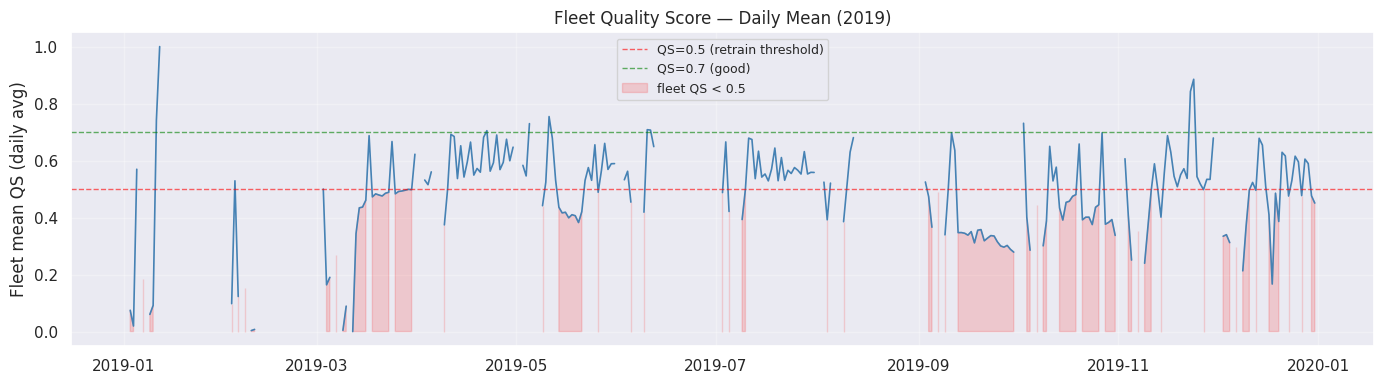

In [5]:
import pandas as pd

qs_arr = qs.values                          # (N, T)
lats   = ds['lat'].values
lons   = ds['lon'].values
times  = pd.DatetimeIndex(ds['time'].values)
N, T   = qs_arr.shape

# Per-plant mean QS (daytime only: pvgis_ref > 0.1 kW/kWp)
pvgis  = ds['pvgis_ref'].values             # (N, T)  kW/kWp
day    = pvgis > 0.1
qs_day = np.where(day, qs_arr, np.nan)
qs_plant_mean = np.nanmean(qs_day, axis=1)  # (N,)

# Fleet daily mean QS
qs_fleet_hourly = pd.Series(np.nanmean(qs_arr, axis=0), index=times)
qs_fleet_daily  = qs_fleet_hourly.resample('1D').mean()

# Monthly fleet mean
qs_monthly = qs_fleet_hourly.resample('ME').mean()

# --- Text report ---
qs_valid = qs_arr[~np.isnan(qs_arr)]
qs_day_valid = qs_day[~np.isnan(qs_day)]
print("=== QUALITY SCORE REPORT ===")
print(f"  Shape: {N} plants × {T} timesteps")
print(f"  Valid QS values: {len(qs_valid):,} / {qs_arr.size:,} ({len(qs_valid)/qs_arr.size*100:.1f}%)")
print(f"  Daytime valid:   {len(qs_day_valid):,} ({len(qs_day_valid)/qs_arr.size*100:.1f}%)")
print(f"\n  GLOBAL (all valid):")
print(f"    mean={np.nanmean(qs_valid):.3f}  median={np.nanmedian(qs_valid):.3f}  std={np.nanstd(qs_valid):.3f}")
print(f"    p10={np.nanpercentile(qs_valid,10):.3f}  p25={np.nanpercentile(qs_valid,25):.3f}"
      f"  p75={np.nanpercentile(qs_valid,75):.3f}  p90={np.nanpercentile(qs_valid,90):.3f}")
print(f"\n  DAYTIME ONLY:")
print(f"    mean={np.nanmean(qs_day_valid):.3f}  median={np.nanmedian(qs_day_valid):.3f}  std={np.nanstd(qs_day_valid):.3f}")
print(f"\n  PER-PLANT (daytime mean):")
print(f"    min={qs_plant_mean.min():.3f}  max={qs_plant_mean.max():.3f}"
      f"  mean={qs_plant_mean.mean():.3f}  std={qs_plant_mean.std():.3f}")
print(f"    plants QS>0.7: {(qs_plant_mean>0.7).sum()}  QS 0.5-0.7: {((qs_plant_mean>=0.5)&(qs_plant_mean<=0.7)).sum()}"
      f"  QS<0.5: {(qs_plant_mean<0.5).sum()}")
print(f"\n  MONTHLY fleet mean:")
for mo, val in qs_monthly.items():
    bar = '█' * int(val * 30)
    print(f"    {mo.strftime('%b'):>3}: {val:.3f}  {bar}")

# --- Fleet QS daily time series ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(qs_fleet_daily.index, qs_fleet_daily.values, linewidth=1.2, color='steelblue')
ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, linewidth=1, label='QS=0.5 (retrain threshold)')
ax.axhline(0.7, color='green',  linestyle='--', alpha=0.6, linewidth=1, label='QS=0.7 (good)')
ax.fill_between(qs_fleet_daily.index, qs_fleet_daily.values, 0,
                where=qs_fleet_daily.values < 0.5, alpha=0.15, color='red', label='fleet QS < 0.5')
ax.set_ylabel('Fleet mean QS (daily avg)')
ax.set_title('Fleet Quality Score — Daily Mean (2019)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

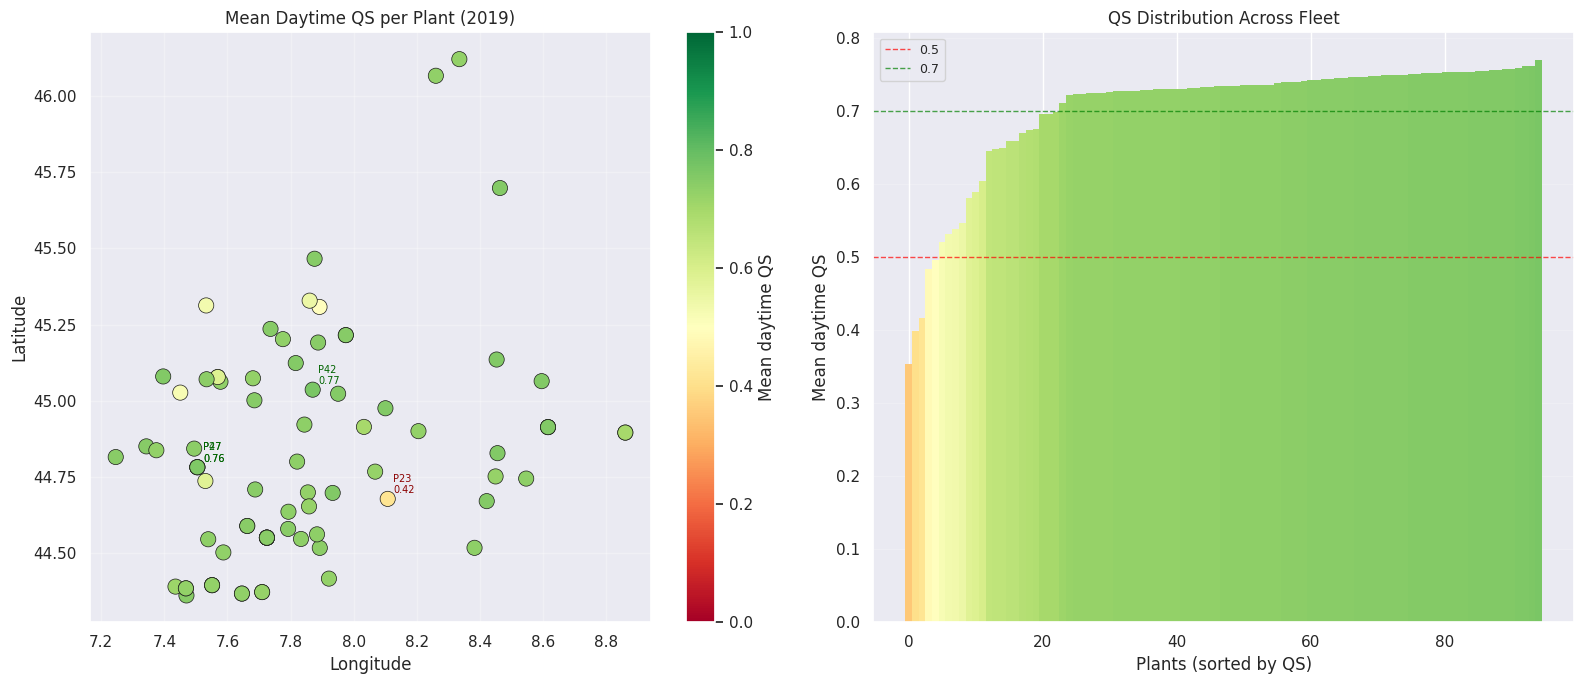

=== SPATIAL QS ===
  Top-5 plants (highest QS):
    1. Plant 42: QS=0.769  lat=45.036  lon=7.870
    2. Plant 27: QS=0.762  lat=44.781  lon=7.504
    3. Plant 47: QS=0.761  lat=44.781  lon=7.504
    4. Plant 91: QS=0.759  lat=44.549  lon=7.725
    5. Plant 11: QS=0.757  lat=45.079  lon=7.396
  Bottom-5 plants (lowest QS):
    1. Plant 20: QS=0.354  lat=nan  lon=nan
    2. Plant 52: QS=0.399  lat=nan  lon=nan
    3. Plant 23: QS=0.417  lat=44.677  lon=8.108
    4. Plant 67: QS=0.484  lat=44.383  lon=7.468
    5. Plant 53: QS=0.497  lat=45.308  lon=7.891


In [6]:
# Spatial map: plants colored by mean daytime QS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: QS map
ax = axes[0]
sc = ax.scatter(lons, lats, c=qs_plant_mean, s=120,
                cmap='RdYlGn', vmin=0.0, vmax=1.0,
                edgecolors='k', linewidth=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='Mean daytime QS')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mean Daytime QS per Plant (2019)')
ax.grid(True, alpha=0.3)

# Annotate top-3 and bottom-3
top3    = np.argsort(qs_plant_mean)[-3:][::-1]
bottom3 = np.argsort(qs_plant_mean)[:3]
for idx in top3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkgreen',
                xytext=(4, 4), textcoords='offset points')
for idx in bottom3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkred',
                xytext=(4, 4), textcoords='offset points')

# Right: QS distribution per plant (sorted bar)
ax2 = axes[1]
order = np.argsort(qs_plant_mean)
colors = plt.cm.RdYlGn(qs_plant_mean[order])
ax2.bar(range(N), qs_plant_mean[order], color=colors, edgecolor='none', width=1.0)
ax2.axhline(0.5, color='red',   linestyle='--', linewidth=1, alpha=0.7, label='0.5')
ax2.axhline(0.7, color='green', linestyle='--', linewidth=1, alpha=0.7, label='0.7')
ax2.set_xlabel('Plants (sorted by QS)')
ax2.set_ylabel('Mean daytime QS')
ax2.set_title('QS Distribution Across Fleet')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

# Text: top/bottom 5
print("=== SPATIAL QS ===")
print("  Top-5 plants (highest QS):")
for i, idx in enumerate(np.argsort(qs_plant_mean)[-5:][::-1]):
    print(f"    {i+1}. Plant {idx:>2}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")
print("  Bottom-5 plants (lowest QS):")
for i, idx in enumerate(np.argsort(qs_plant_mean)[:5]):
    print(f"    {i+1}. Plant {idx:>2}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")

In [7]:
# Plant size estimates (kWp) and per-plant PR
pv_scale_arr  = dataset.pv_scale   # (N,) p99 ENERGIA daytime [kWh]
pvgis_p99_arr = dataset.pvgis_p99  # (N,) p99 pvgis_ref daytime [kW/kWp]
eta_adj_arr   = dataset.eta_adjusted  # (N,) actual per-plant eta in normalised space

# kWp estimate: p99(ENERGIA_day) / p99(pvgis_ref_day)
kWp_est = pv_scale_arr / pvgis_p99_arr  # (N,)

# Actual PR = eta_adjusted * pvgis_p99  (back to physical space)
pr_actual = eta_adj_arr * pvgis_p99_arr

print("=== PER-PLANT SIZE AND PERFORMANCE RATIO ===")
print(f"  {'Plant':>5}  {'kWp_est':>8}  {'PR_actual':>9}  {'pv_scale':>9}  {'pvgis_p99':>9}  {'eta_adj':>8}")
print(f"  {'-'*5}  {'-'*8}  {'-'*9}  {'-'*9}  {'-'*9}  {'-'*8}")
for p in range(len(kWp_est)):
    print(f"  {p:>5}  {kWp_est[p]:>8.1f}  {pr_actual[p]:>9.3f}  {pv_scale_arr[p]:>9.1f}  {pvgis_p99_arr[p]:>9.3f}  {eta_adj_arr[p]:>8.3f}")

print(f"\n  FLEET SUMMARY:")
print(f"  kWp  — min={kWp_est.min():.1f}  max={kWp_est.max():.1f}  mean={kWp_est.mean():.1f}  median={np.median(kWp_est):.1f}")
print(f"  PR   — min={pr_actual.min():.3f}  max={pr_actual.max():.3f}  mean={pr_actual.mean():.3f}  std={pr_actual.std():.3f}")
print(f"  Note: kWp_est = p99(ENERGIA_day) / p99(pvgis_ref_day)")
print(f"        PR = actual median(ENERGIA / (kWp * pvgis_ref)) — fully data-driven, no assumption")

=== PER-PLANT SIZE AND PERFORMANCE RATIO ===
  Plant   kWp_est  PR_actual   pv_scale  pvgis_p99   eta_adj
  -----  --------  ---------  ---------  ---------  --------
      0     537.4      0.754      386.0      0.718     1.050
      1     107.6      0.748       76.7      0.712     1.050
      2     282.5      0.769      207.0      0.733     1.050
      3     173.5      0.775      128.0      0.738     1.050
      4    1166.9      0.756      839.7      0.720     1.050
      5    1143.9      0.760      828.4      0.724     1.050
      6      78.3      0.751       56.0      0.715     1.050
      7    1053.6      0.774      777.0      0.737     1.050
      8     956.4      0.749      682.4      0.714     1.050
      9      58.4      0.774       43.0      0.737     1.050
     10    1066.5      0.748      760.0      0.713     1.050
     11     902.4      0.760      653.0      0.724     1.050
     12     532.3      0.775      392.7      0.738     1.050
     13     438.2      0.759      316.8 